<a href="https://colab.research.google.com/github/shown5/Hands-on-Generative-AI/blob/main/chap5_StableDiffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

５章 Stable Diffusion と条件付き生成

前章までで画像の生成はできるようになったが、モデルの訓練には時間がかかり、生成される画像を制御することはできなかった。
本章ではより発展的に、テキストの説明に基づいて効率的に画像を生成できる、テキスト条件付きモデルへと発展させる方法を、Stable Diffusion を事例として見ていく。

その前に、まず条件付きモデルがどのように動作するかを確認し、現在のテキストから画像への生成モデルにつながる技術革新について振り返る。

5.1 制御の追加：条件付き拡散モデル

モデルの出力を制御する方法の一つに**条件付け**がある。
これはモデルに対して「どんな画像でも良い」とするのではなく、「あらかじめ決められたクラスに属する画像を生成せよ」と指示を与えるもの。
生成の過程でラベルやプロンプトなどの追加情報を与え、モデルの出力を誘導することを指す。

データセットは前章の蝶の画像の代わりに、画像にクラスラベルが付与された衣服画像のデータセットを用いる。
ポイントは、画像に加えて、画像が属するクラスラベルも入力に用いる点。
これによりモデルが画像とラベルの間の関連性を学び、特徴を理解できるようになることを期待する。

分類問題を解決することを目的としていない点に注意。
目的は前章と同じく、使用するデータセットから生成されたような最もらしい画像を生成させたいということ。
訓練の方法や損失関数は前章と同じものを使う。なぜなら本質的には本章でも同じタスクだから。

5.1.1 データの準備

今回は Fashion MNIST を使う。

In [1]:
%pip install genaibook

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.4/290.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.4 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
  Attempting uninstall: huggingface_hub
    Found exi

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…):   0%|          | 0.00/30.9M [00:00<?, ?B/s]

fashion_mnist/test-00000-of-00001.parque(…):   0%|          | 0.00/5.18M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

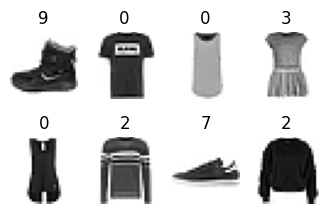

In [2]:
import matplotlib as mpl
from datasets import load_dataset

from genaibook.core import show_images

mpl.rcParams["image.cmap"] = "gray_r"

fashion_mnist = load_dataset("fashion_mnist")
clothes = fashion_mnist["train"]["image"][:8]
classes = fashion_mnist["train"]["label"][:8]
show_images(clothes, titles=classes, figsize=(4, 2.5))

今回は画像を 32 * 32 ピクセルにパディングする。

In [7]:
import torch
from torchvision import transforms

preprocess = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Pad(2),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

def transform(examples):
  images = [preprocess(image) for image in examples["image"]]
  return {"images": images, "labels": examples["label"]}


train_dataset = fashion_mnist["train"].with_transform(transform)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=256, shuffle=True
)

5.1.2 クラス条件付きモデルの作成

UNet はカスタムの条件付け情報を与えることができる。
コンストラクタに num_class_embeds を追加するだけ。
Fashion MNIST のクラスすうが１０個なので、この引数に渡す値も１０とする。

In [8]:
from diffusers import UNet2DModel

model = UNet2DModel(
    in_channels=1,
    out_channels=1,
    sample_size=32,
    block_out_channels=(32, 64, 128, 256),
    num_class_embeds=10
)

このモデルで予測を行うには forward() メソッドにクラスラベルを追加で渡す必要がある

In [9]:
x = torch.randn((1, 1, 32, 32))
with torch.inference_mode():
  out = model(x, timestep=7, class_labels=torch.tensor([2])).sample
out.shape

torch.Size([1, 1, 32, 32])

5.1.3 モデルの訓練

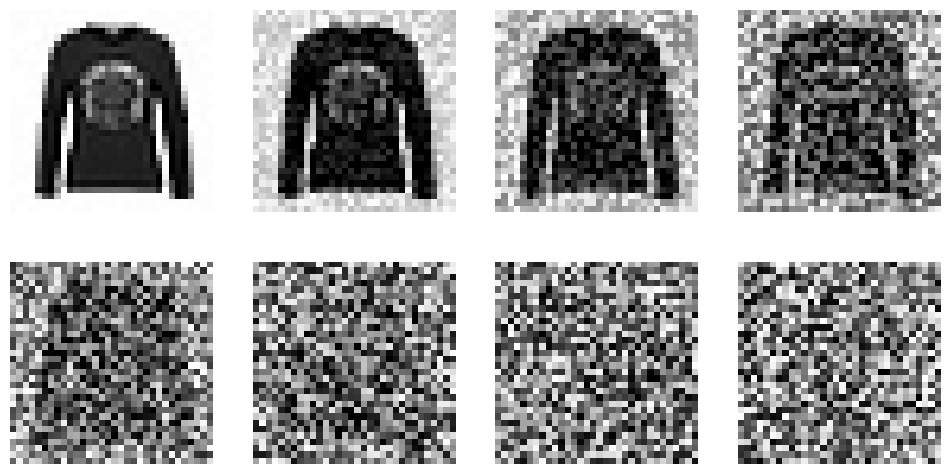

In [10]:
from diffusers import DDPMScheduler

scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.001, beta_end=0.02
)
timesteps = torch.linspace(0, 999, 8).long()
batch = next(iter(train_dataloader))

# データセットから８名の画像を読み込みノイズの量を徐々に増やしていく
x = batch["images"][0].expand([8, 1, 32, 32])
noise = torch.rand_like(x)
noised_x = scheduler.add_noise(x, noise, timesteps)
show_images((noised_x * 0.5 + 0.5).clip(0, 1))

In [ ]:
from torch.nn import functional as F
from tqdm import tqdm

from genaibook.core import get_device

#スケジューラー初期化
schedeler = DDPMScheduler(
    num_train_timesteps=1000, beta_start=0.0001, beta_end=0.02
)

num_epochs = 25
lr = 3e-4 #学習率
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, eps=1e-5)
losses = [] #後で表示するために損失を保存しておくリスト

device = get_device()
model = model.to(device)

#モデルを訓練する（時間かかる）
for epoch in (progress := tqdm(range(num_epochs))):
  for step, batch in(
      inner := tqdm(
          enumerate(train_dataloader),
          position=0,
          leave=True,
          total=len(train_dataloader)
      )
  ):
    #入力画像とクラスを読み込む
    clean_images = batch["images"].to(device)
    class_labels = batch["labels"].to(device)

    #画像に加えるノイズをサンプリングする
    noise = torch.randn(clean_images.shape).to(device)

    #各画像ごとにランダムなタイムステップをサンプリングする
    timesteps = torch.randint(
        0,
        scheduler.config.num_train_timesteps,
        (clean_images.shape[0],),
        device=device
    ).long()

    #タイムステップごとのノイズ量に従って画像にノイズを加える
    noisy_images = scheduler.add_noise(clean_images, noise, timesteps)

    #ノイズに対するモデルの予測値を得る
    #モデルにクラスラベルを渡している点に注目
    noise_pred = model(noisy_images, timesteps, class_labels=class_labels, return_dict=False)[0]

    #予測値と実際のノイズを比較する
    loss = F.mse_loss(noise_pred, noise)

    # 損失を更新し、表示する
    inner.set_postfix(loss=f"{loss.cpu().item():.3f}")

    #後で表示できるように損失を保存する
    losses.append(loss.item())

    #この損失に基づきモデルのパラメーターを更新する
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)